In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import dask.dataframe as dd
import dask.array as da
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [41]:
#getting the geometry frame. We want this to calculate the mean of upgrade om x and y positions
gcd_infile = dataio.I3File('/home/akatil/GeoCalibDetectorStatus_ICUpgrade.v58.mixed.V1.i3.bz2')

f_geo = gcd_infile
geo_frame = f_geo.pop_frame(icetray.I3Frame.Geometry)
geo = geo_frame['I3Geometry']

ux, uy, uz = get_mean_upgrade_positions(geo)

fCC = tables.open_file('../../../dataset_complete/merger/merged_CC_0.h5', mode='r')
fNC = tables.open_file('../../../dataset_complete/merger/merged_NC_0.h5', mode='r')

In [4]:
emin, emax = 0, 100

def get_boolean(f, interaction_type):
    if interaction_type == 0:
        energy = f.root.OMMapTrue.col('om_penergy')

    if interaction_type == 1:
        energy = f.root.OMMapTrue.col('om_senergy')

    renergy = f.root.OMMapReco.col('om_renergy')

    energy_boolean = (energy >= emin) & (energy <= emax)
    reco_energy_boolean = (renergy >= emin) & (renergy <= emax)

    om_boolean = energy_boolean
    reco_om_boolean = reco_energy_boolean

    return om_boolean, reco_om_boolean

In [5]:
om_booleanCC, reco_om_booleanCC = get_boolean(fCC, 0)
om_booleanNC, reco_om_booleanNC = get_boolean(fNC, 1)

In [6]:
def make_plots(true_xCC, true_yCC, 
               true_xNC, true_yNC, 
               reco_xCC, reco_yCC,
               reco_xNC, reco_yNC,
               bins, 
               xlabel, ylabel):

    true_xCC_m = true_xCC[~np.isnan(true_xCC)]
    true_yCC_m = true_yCC[~np.isnan(true_xCC)]
    true_xNC_m = true_xNC[~np.isnan(true_xNC)]
    true_yNC_m = true_yNC[~np.isnan(true_xNC)]
    reco_xCC_m = reco_xCC[~np.isnan(reco_xCC)]
    reco_yCC_m = reco_yCC[~np.isnan(reco_xCC)]
    reco_xNC_m = reco_xNC[~np.isnan(reco_xNC)]
    reco_yNC_m = reco_yNC[~np.isnan(reco_xNC)]

    hist_CC, _, _ = np.histogram2d(true_xCC_m, true_yCC_m, bins=bins, density=True)
    hist_NC, _, _ = np.histogram2d(true_xNC_m, true_yNC_m, bins=bins, density=True)
    
    #replace zeros to avoid log scale errors
    #hist_CC[hist_CC == 0] = np.nan
    #hist_NC[hist_NC == 0] = np.nan
    masked_CC = np.ma.masked_where(hist_CC == 0, hist_CC)
    masked_NC = np.ma.masked_where(hist_NC == 0, hist_NC)

    vmin = min(masked_CC.min(), masked_NC.min())
    vmax = max(masked_CC.max(), masked_NC.max())
    
    #compute global min/max ignoring nans
    #vmin = np.nanmin([hist_CC.min(), hist_NC.min()])
    #vmax = np.nanmax([hist_CC.max(), hist_NC.max()])
    norm = LogNorm(vmin=vmin, vmax=vmax)

    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(8)
    fig.set_figwidth(20)
    
    a0 = axs[0].hist2d(true_xCC_m, true_yCC_m, cmap='jet', norm=norm, density=True, bins=bins)
    fig.colorbar(a0[3], ax=axs[0])
    axs[0].set_xlabel(xlabel, fontsize = 18)
    axs[0].set_ylabel(ylabel, fontsize = 18)
    axs[0].set_title('CC - Energy {} - {} GeV|True'.format(emin, emax))

    #print(len(xNC), len(yNC))
    a1 = axs[1].hist2d(true_xNC_m, true_yNC_m, cmap='jet', norm=norm, density=True, bins=bins)
    fig.colorbar(a1[3], ax=axs[1])
    axs[1].set_xlabel(xlabel, fontsize = 18)
    axs[1].set_ylabel(ylabel, fontsize = 18)
    axs[1].set_title('NC - Charge {} - {} GeV|True'.format(emin, emax))
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

    hist_CC, _, _ = np.histogram2d(reco_xCC_m, reco_yCC_m, bins=bins, density=True)
    hist_NC, _, _ = np.histogram2d(reco_xNC_m, reco_yNC_m, bins=bins, density=True)
    
    # Replace zeros to avoid log scale errors
    #hist_CC[hist_CC == 0] = np.nan
    #hist_NC[hist_NC == 0] = np.nan
    masked_CC = np.ma.masked_where(hist_CC == 0, hist_CC) #masking zero values
    masked_NC = np.ma.masked_where(hist_NC == 0, hist_NC)

    vmin = min(masked_CC.min(), masked_NC.min())
    vmax = max(masked_CC.max(), masked_NC.max())
    
    # Compute global min/max ignoring nans
    #vmin = np.nanmin([hist_CC.min(), hist_NC.min()])
    #vmax = np.nanmax([hist_CC.max(), hist_NC.max()])
    norm = LogNorm(vmin=vmin, vmax=vmax)

    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(8)
    fig.set_figwidth(20)
    
    a0 = axs[0].hist2d(reco_xCC_m, reco_yCC_m, cmap='jet', norm=norm, density=True, bins=bins)
    fig.colorbar(a0[3], ax=axs[0])
    axs[0].set_xlabel(xlabel, fontsize = 18)
    axs[0].set_ylabel(ylabel, fontsize = 18)
    axs[0].set_title('CC - Energy {} - {} GeV|Reco'.format(emin, emax))

    #print(len(xNC), len(yNC))
    a1 = axs[1].hist2d(reco_xNC_m, reco_yNC_m, cmap='jet', norm=norm, density=True, bins=bins)
    fig.colorbar(a1[3], ax=axs[1])
    axs[1].set_xlabel(xlabel, fontsize = 18)
    axs[1].set_ylabel(ylabel, fontsize = 18)
    axs[1].set_title('NC - Charge {} - {} GeV|Reco'.format(emin, emax))
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

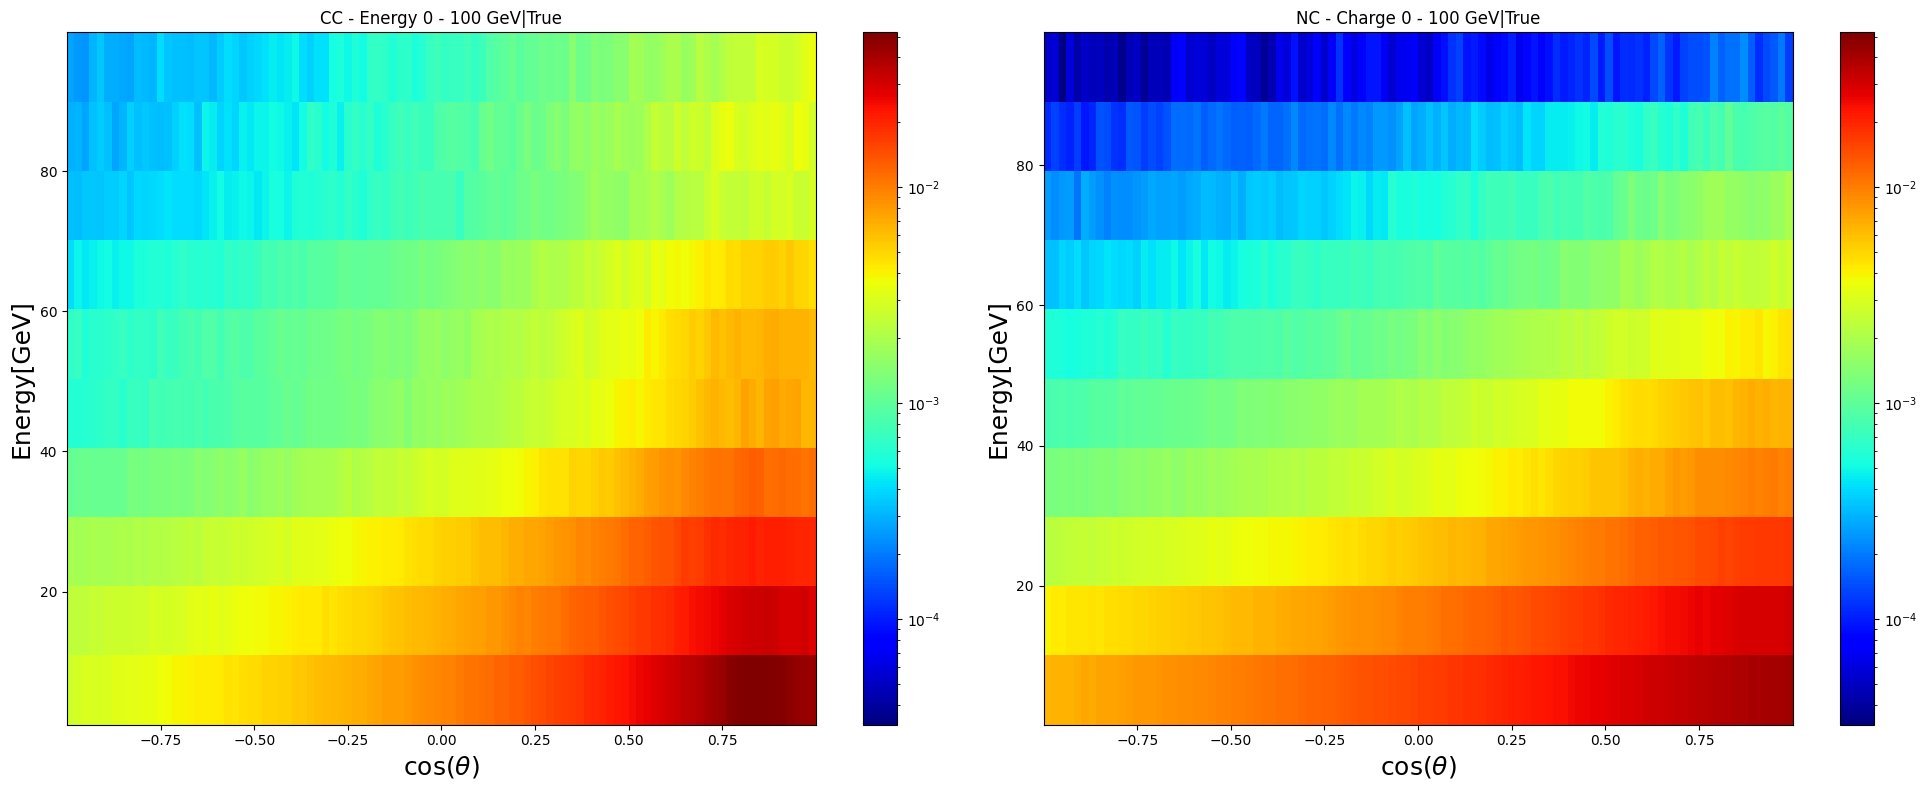

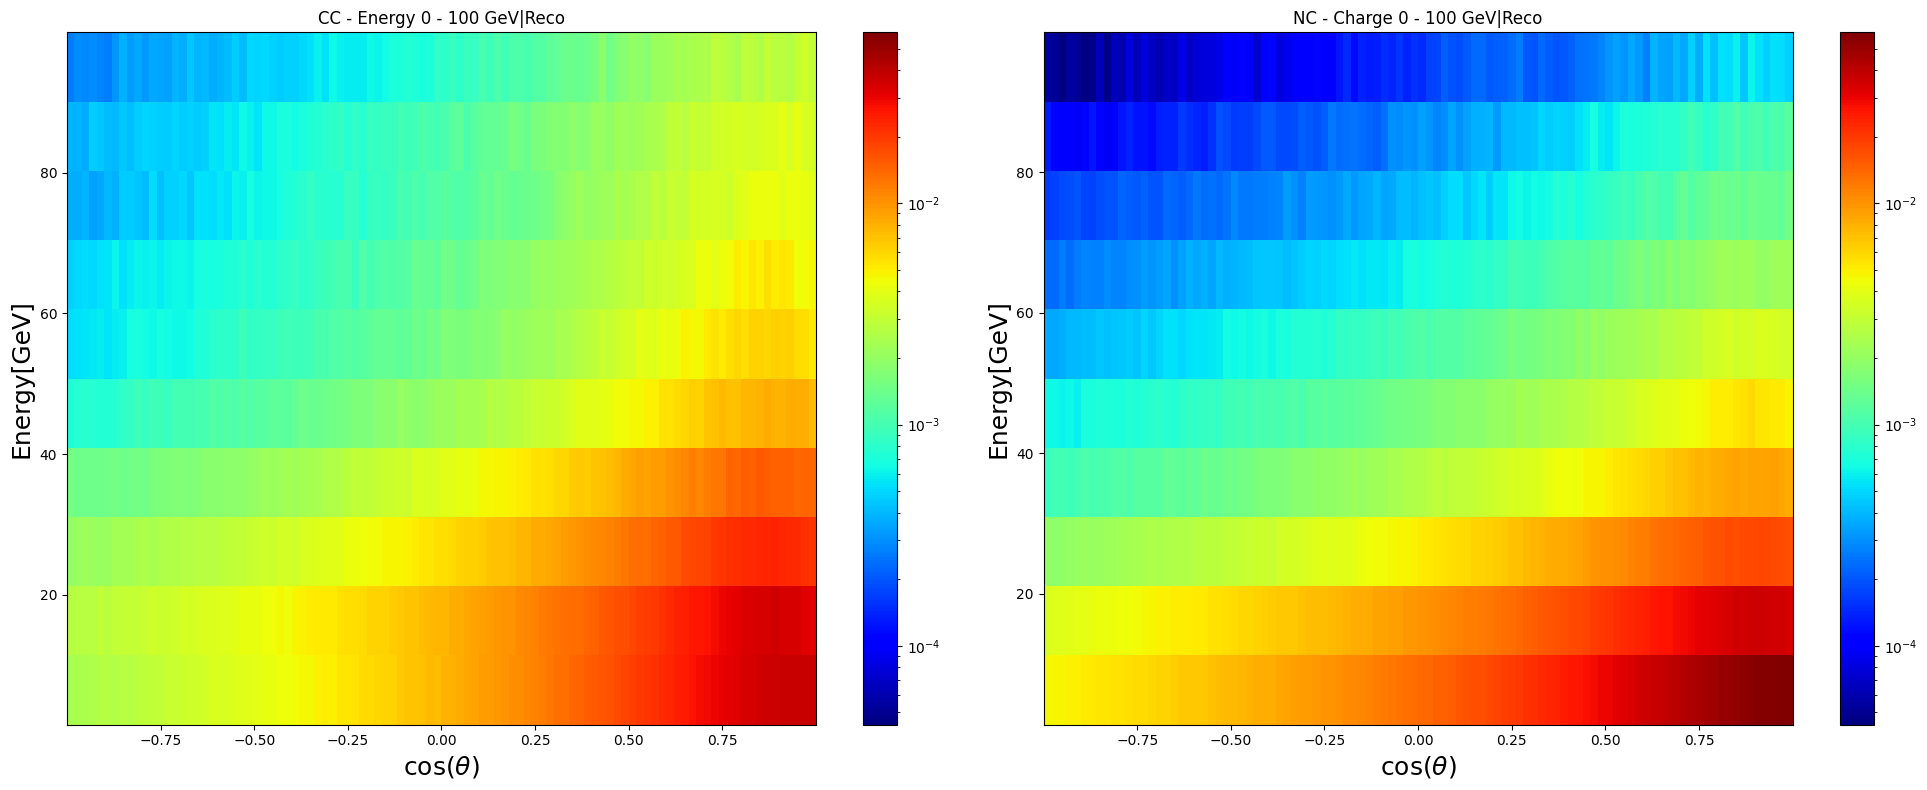

In [7]:
make_plots(np.cos(fCC.root.OMMapTrue.col('angle')), fCC.root.OMMapTrue.col('om_penergy'),
           np.cos(fNC.root.OMMapTrue.col('angle')), fNC.root.OMMapTrue.col('om_senergy'),
           np.cos(fCC.root.OMMapReco.col('angle')[reco_om_booleanCC]), fCC.root.OMMapReco.col('om_renergy')[reco_om_booleanCC],
           np.cos(fNC.root.OMMapReco.col('angle')[reco_om_booleanNC]), fNC.root.OMMapReco.col('om_renergy')[reco_om_booleanNC],
           (100, 10), 
           r'$\cos (\theta)$', "Energy[GeV]")

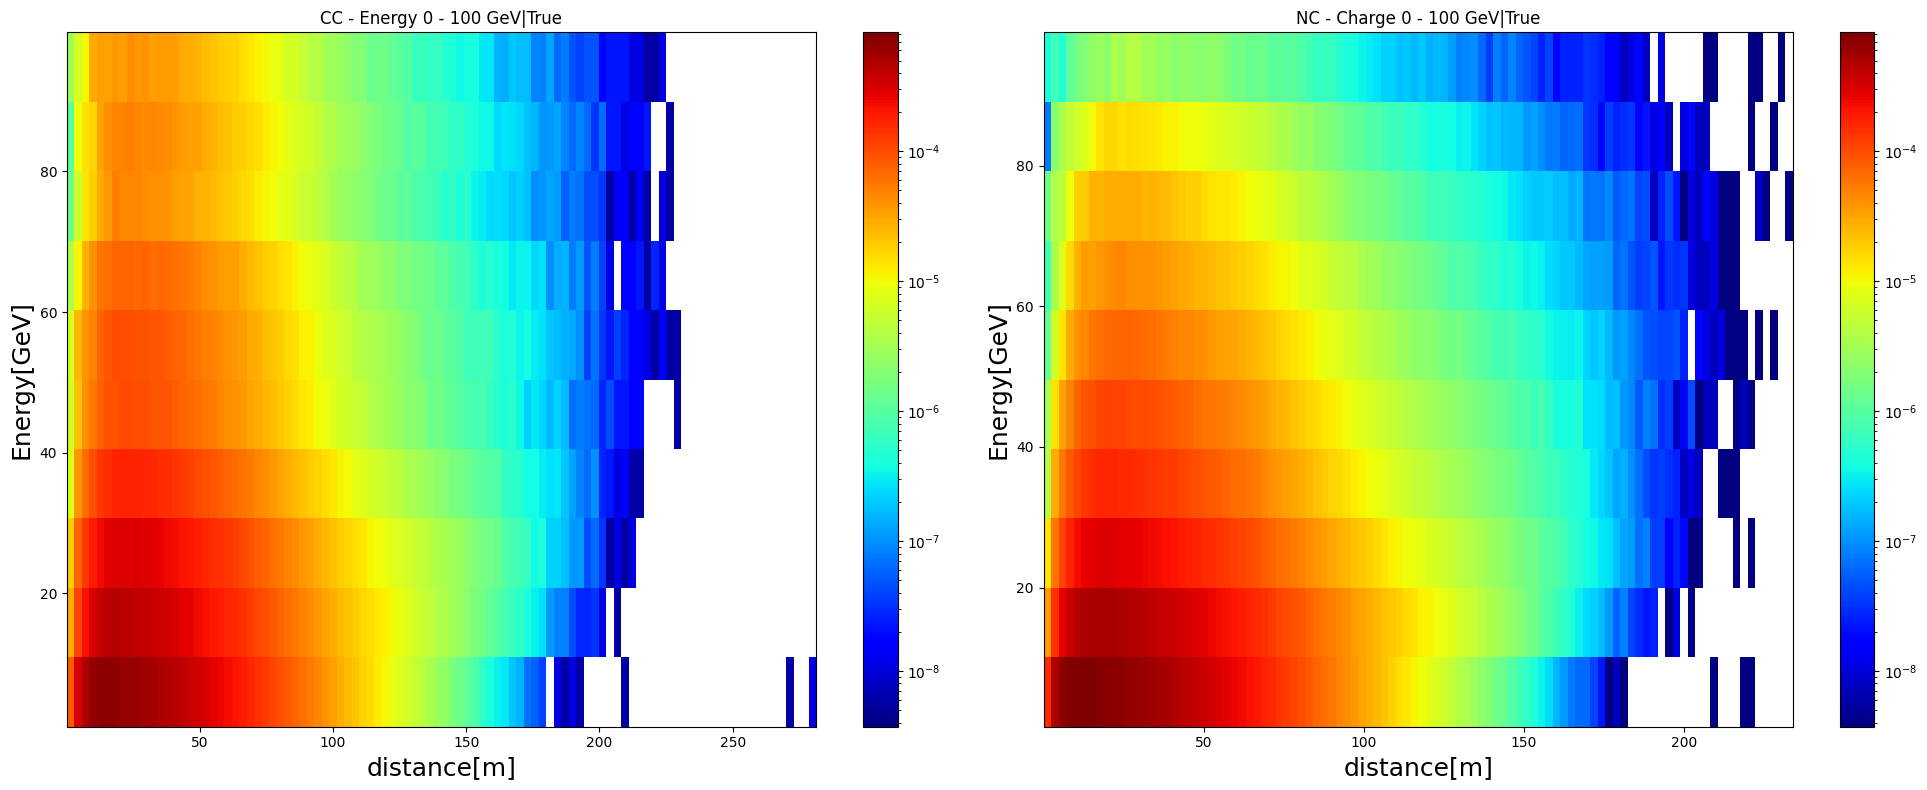

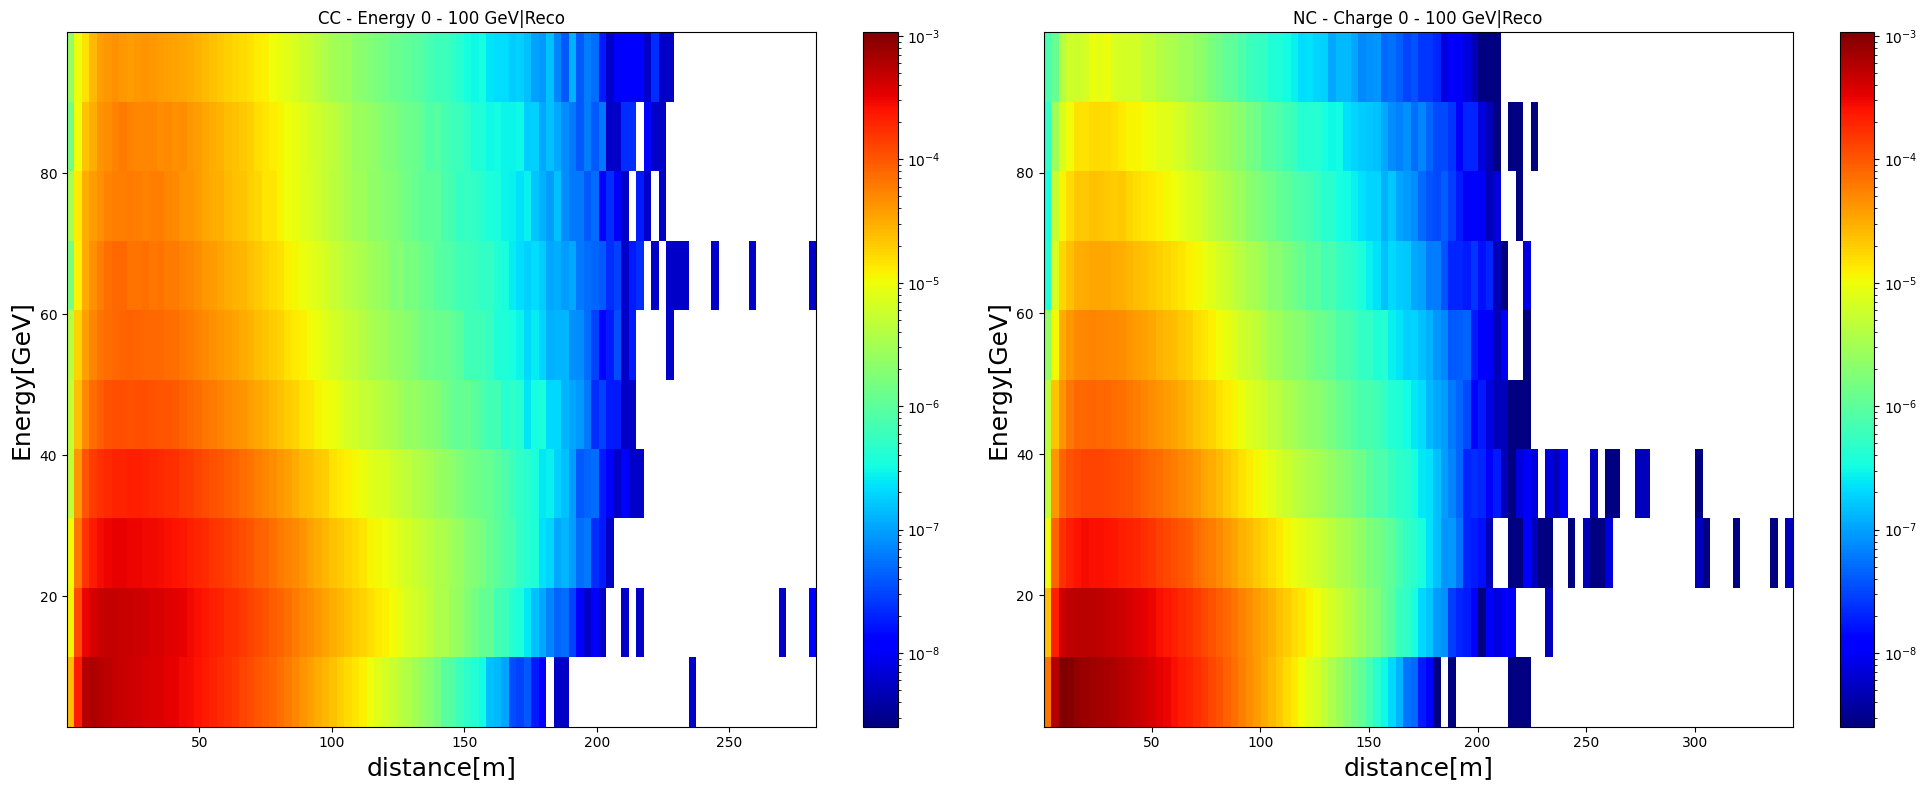

In [8]:
make_plots(fCC.root.OMMapTrue.col('distance'), fCC.root.OMMapTrue.col('om_penergy'),
           fNC.root.OMMapTrue.col('distance'), fNC.root.OMMapTrue.col('om_senergy'),
           fCC.root.OMMapReco.col('distance')[reco_om_booleanCC], fCC.root.OMMapReco.col('om_renergy')[reco_om_booleanCC],
           fNC.root.OMMapReco.col('distance')[reco_om_booleanNC], fNC.root.OMMapTrue.col('om_renergy')[reco_om_booleanNC],
           (100, 10), 
           'distance[m]', "Energy[GeV]")

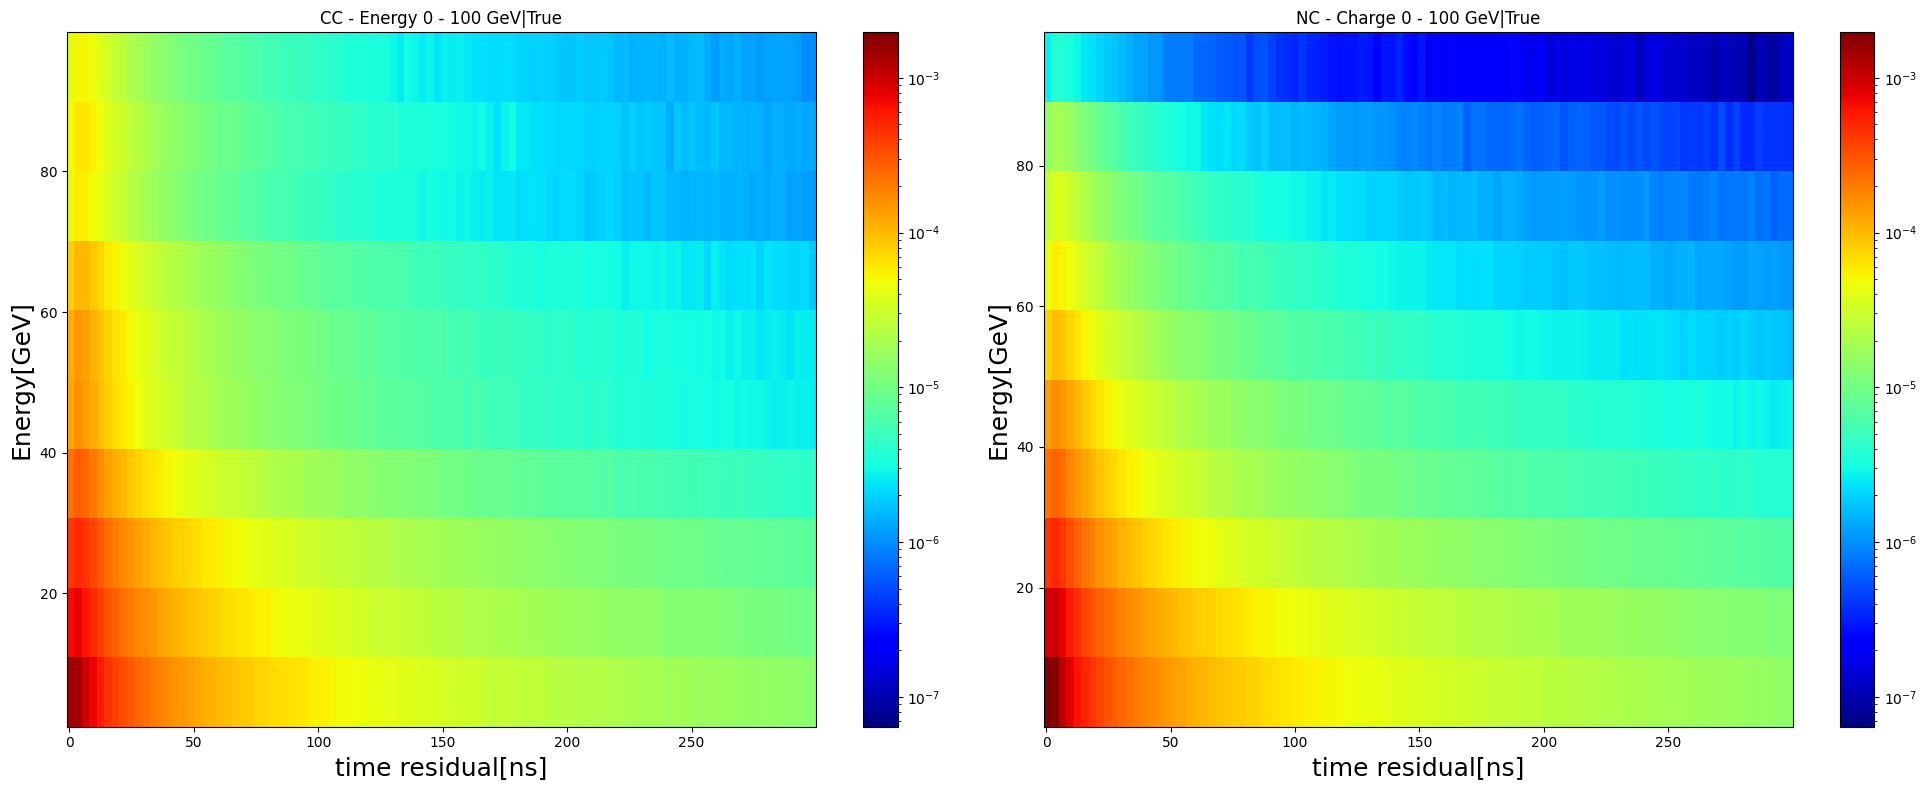

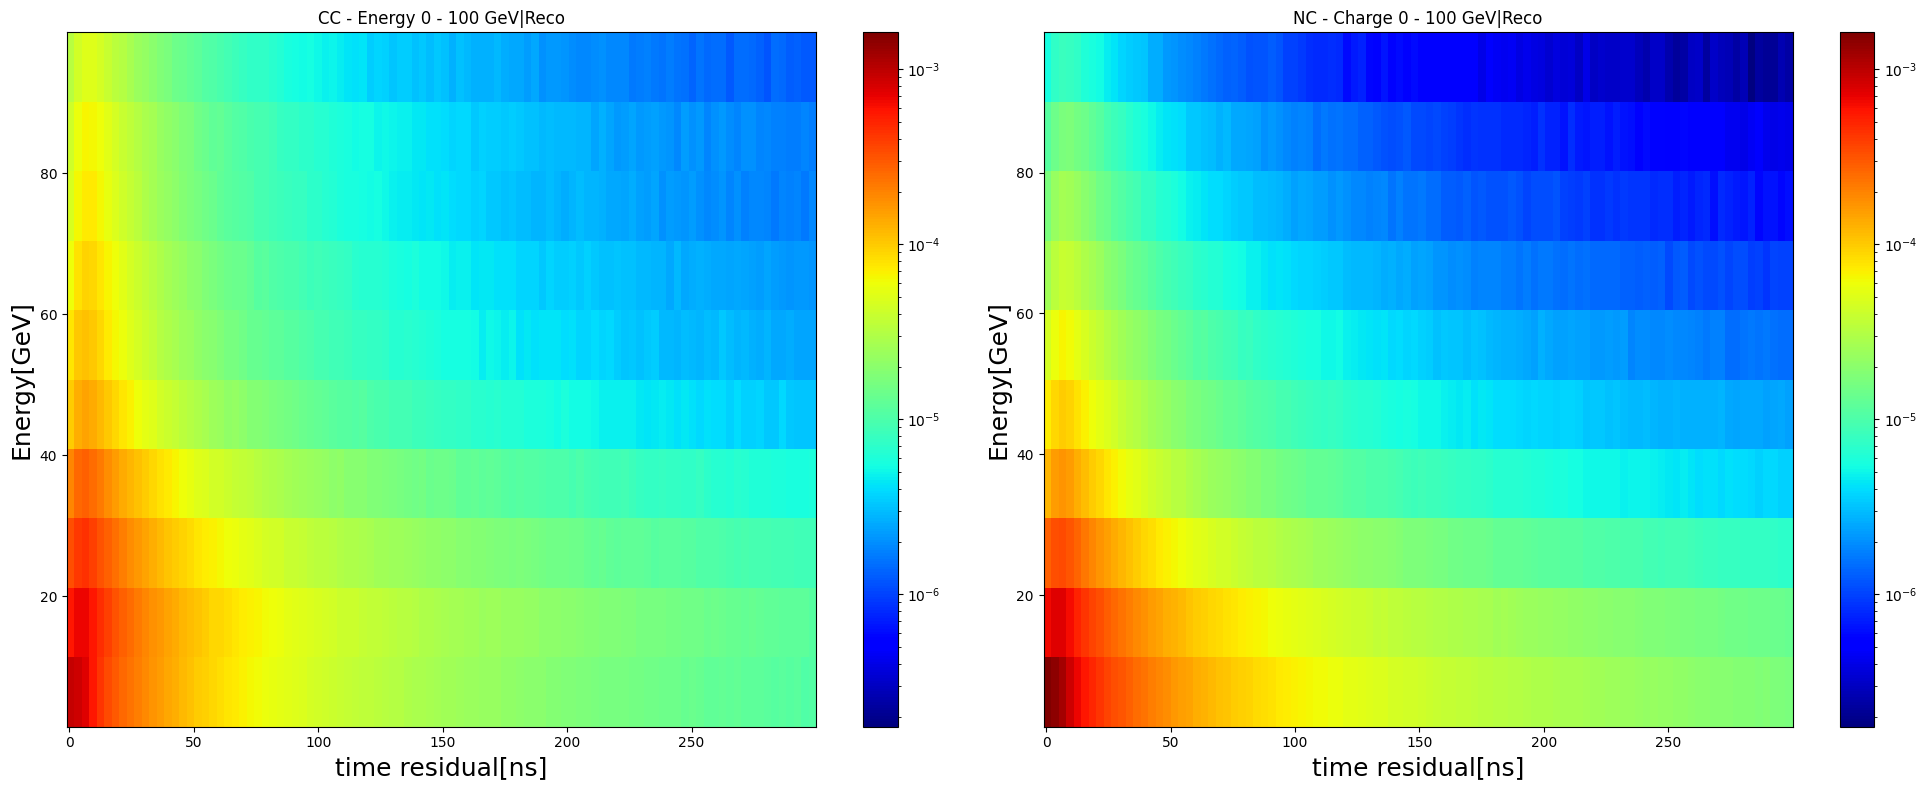

In [10]:
true_CC = fCC.root.OMMapTrue.col('time_residual')
true_energy_CC = fCC.root.OMMapTrue.col('om_penergy')

true_NC = fNC.root.OMMapTrue.col('time_residual')
true_energy_NC = fNC.root.OMMapTrue.col('om_senergy')

reco_CC = fCC.root.OMMapReco.col('time_residual')[reco_om_booleanCC]
reco_energy_CC = fCC.root.OMMapReco.col('om_renergy')[reco_om_booleanCC]

reco_NC = fNC.root.OMMapReco.col('time_residual')[reco_om_booleanNC]
reco_energy_NC = fNC.root.OMMapReco.col('om_renergy')[reco_om_booleanNC]

min_val = -1
max_val = 300

   
true_maskCC = (true_CC>=min_val)&(true_CC<=max_val)
true_maskNC = (true_NC>=min_val)&(true_NC<=max_val)

reco_maskCC = (reco_CC>=min_val)&(reco_CC<=max_val)
reco_maskNC = (reco_NC>=min_val)&(reco_NC<=max_val)

make_plots(true_CC[true_maskCC], true_energy_CC[true_maskCC],
           true_NC[true_maskNC], true_energy_NC[true_maskNC],
           reco_CC[reco_maskCC], reco_energy_CC[reco_maskCC],
           reco_NC[reco_maskNC], reco_energy_NC[reco_maskNC],
           (100, 10), 
           'time residual[ns]', "Energy[GeV]")

In [12]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC, energy=True):
    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]

    if energy:
        max_val = 10
    else:
        max_val = 30 #charge
    
    for i in range(0, max_val):#range(0, len(charge_val)-1):#
        qmin= i*10 #charge_val[i]#
        qmax= (i+1)*10 #charge_val[i+1]#
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len( xNC[maskNC]) != 0:
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax-0.5) #append(qmax - 5)

    return sep_var, p_val, bin_centers

In [14]:
#Using energy

sep_var_angle_true, p_val_angle_true, bin_centers_angle_true = get_statistic(np.cos(fCC.root.OMMapTrue.col('angle')), np.cos(fNC.root.OMMapTrue.col('angle')), 
                                              fCC.root.OMMapTrue.col('om_penergy'), fNC.root.OMMapTrue.col('om_senergy'))

sep_var_angle_reco, p_val_angle_reco, bin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

sep_var_distance_true, p_val_distance_true, bin_centers_distance_true = get_statistic(fCC.root.OMMapTrue.col('distance'), fNC.root.OMMapTrue.col('distance'), 
                                              fCC.root.OMMapTrue.col('om_penergy'), fNC.root.OMMapTrue.col('om_senergy'))

sep_var_distance_reco, p_val_distance_reco, bin_centers_distance_reco = get_statistic(fCC.root.OMMapReco.col('distance'), fNC.root.OMMapReco.col('distance'), 
                                              fCC.root.OMMapReco.col('om_renergy'), fNC.root.OMMapReco.col('om_renergy'))

true_CC = fCC.root.OMMapTrue.col('time_residual')
true_energy_CC = fCC.root.OMMapTrue.col('om_penergy')

true_NC = fNC.root.OMMapTrue.col('time_residual')
true_energy_NC = fNC.root.OMMapTrue.col('om_senergy')

reco_CC = fCC.root.OMMapReco.col('time_residual')[reco_om_booleanCC]
reco_energy_CC = fCC.root.OMMapReco.col('om_renergy')[reco_om_booleanCC]

reco_NC = fNC.root.OMMapReco.col('time_residual')[reco_om_booleanNC]
reco_energy_NC = fNC.root.OMMapReco.col('om_renergy')[reco_om_booleanNC]

min_val = -1
max_val = 300
   
true_maskCC = (true_CC>=min_val)&(true_CC<=max_val)
true_maskNC = (true_NC>=min_val)&(true_NC<=max_val)

reco_maskCC = (reco_CC>=min_val)&(reco_CC<=max_val)
reco_maskNC = (reco_NC>=min_val)&(reco_NC<=max_val)

sep_var_tRes_true, p_val_tRes_true, bin_centers_tRes_true = get_statistic(true_CC[true_maskCC], true_NC[true_maskNC], 
                                              true_energy_CC[true_maskCC], true_energy_NC[true_maskNC])

sep_var_tRes_reco, p_val_tRes_reco, bin_centers_tRes_reco = get_statistic(reco_CC[reco_maskCC], reco_NC[reco_maskNC], 
                                              reco_energy_CC[reco_maskCC], reco_energy_NC[reco_maskNC])

In [22]:
#Using Charge

csep_var_angle_true, cp_val_angle_true, cbin_centers_angle_true = get_statistic(np.cos(fCC.root.OMMapTrue.col('angle')), np.cos(fNC.root.OMMapTrue.col('angle')), 
                                              fCC.root.OMMapTrue.col('om_total_charge'), fNC.root.OMMapTrue.col('om_total_charge'), energy=False)

csep_var_angle_reco, cp_val_angle_reco, cbin_centers_angle_reco = get_statistic(np.cos(fCC.root.OMMapReco.col('angle')), np.cos(fNC.root.OMMapReco.col('angle')), 
                                              fCC.root.OMMapReco.col('om_total_charge'), fNC.root.OMMapReco.col('om_total_charge'), energy=False)

csep_var_distance_true, cp_val_distance_true, cbin_centers_distance_true = get_statistic(fCC.root.OMMapTrue.col('distance'), fNC.root.OMMapTrue.col('distance'), 
                                              fCC.root.OMMapTrue.col('om_total_charge'), fNC.root.OMMapTrue.col('om_total_charge'), energy=False)

csep_var_distance_reco, cp_val_distance_reco, cbin_centers_distance_reco = get_statistic(fCC.root.OMMapReco.col('distance'), fNC.root.OMMapReco.col('distance'), 
                                              fCC.root.OMMapReco.col('om_total_charge'), fNC.root.OMMapReco.col('om_total_charge'), energy=False)

true_CC = fCC.root.OMMapTrue.col('time_residual')
true_energy_CC = fCC.root.OMMapTrue.col('om_total_charge')

true_NC = fNC.root.OMMapTrue.col('time_residual')
true_energy_NC = fNC.root.OMMapTrue.col('om_total_charge')

reco_CC = fCC.root.OMMapReco.col('time_residual')[reco_om_booleanCC]
reco_energy_CC = fCC.root.OMMapReco.col('om_total_charge')[reco_om_booleanCC]

reco_NC = fNC.root.OMMapReco.col('time_residual')[reco_om_booleanNC]
reco_energy_NC = fNC.root.OMMapReco.col('om_total_charge')[reco_om_booleanNC]

min_val = -1
max_val = 300
   
true_maskCC = (true_CC>=min_val)&(true_CC<=max_val)
true_maskNC = (true_NC>=min_val)&(true_NC<=max_val)

reco_maskCC = (reco_CC>=min_val)&(reco_CC<=max_val)
reco_maskNC = (reco_NC>=min_val)&(reco_NC<=max_val)

csep_var_tRes_true, cp_val_tRes_true, cbin_centers_tRes_true = get_statistic(true_CC[true_maskCC], true_NC[true_maskNC], 
                                              true_energy_CC[true_maskCC], true_energy_NC[true_maskNC], energy=False)

csep_var_tRes_reco, cp_val_tRes_reco, cbin_centers_tRes_reco = get_statistic(reco_CC[reco_maskCC], reco_NC[reco_maskNC], 
                                              reco_energy_CC[reco_maskCC], reco_energy_NC[reco_maskNC], energy=False)

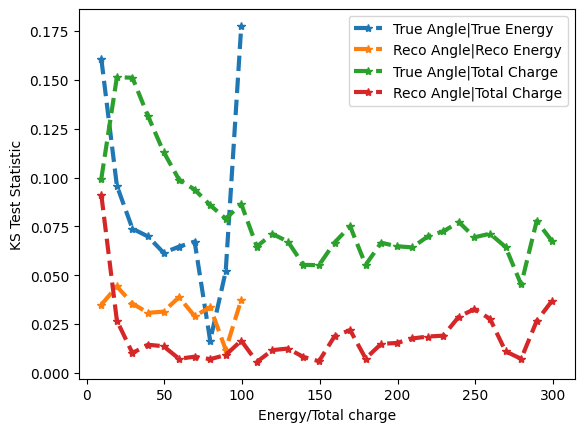

In [23]:
plt.plot(bin_centers_angle_true, sep_var_angle_true, '*--', linewidth=3, label='True Angle|True Energy')
plt.plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=3, label='Reco Angle|Reco Energy')

plt.plot(cbin_centers_angle_true, csep_var_angle_true, '*--', linewidth=3, label='True Angle|Total Charge')
plt.plot(cbin_centers_angle_reco, csep_var_angle_reco, '*--', linewidth=3, label='Reco Angle|Total Charge')

plt.ylabel('KS Test Statistic')
plt.xlabel('Energy/Total charge')
plt.legend()

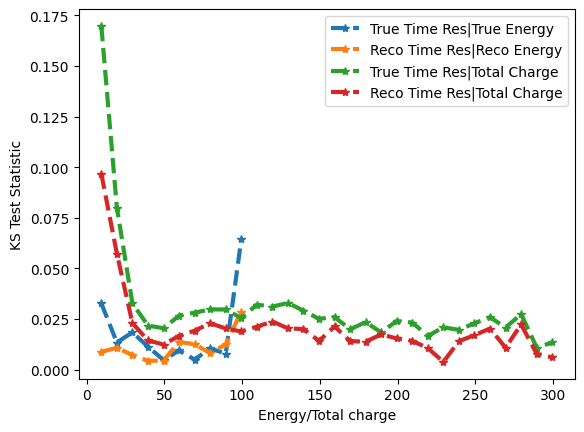

In [24]:
plt.plot(bin_centers_tRes_true, sep_var_tRes_true, '*--', linewidth=3, label='True Time Res|True Energy ')
plt.plot(bin_centers_tRes_reco, sep_var_tRes_reco, '*--', linewidth=3, label='Reco Time Res|Reco Energy')

plt.plot(cbin_centers_tRes_true, csep_var_tRes_true, '*--', linewidth=3, label='True Time Res|Total Charge')
plt.plot(cbin_centers_tRes_reco, csep_var_tRes_reco, '*--', linewidth=3, label='Reco Time Res|Total Charge')

plt.ylabel('KS Test Statistic')
plt.xlabel('Energy/Total charge')
plt.legend()

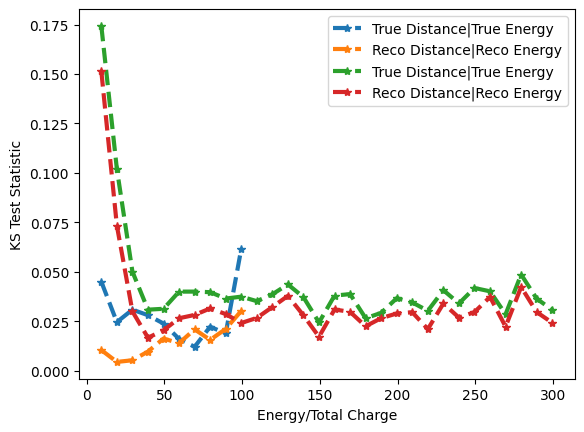

In [25]:
plt.plot(bin_centers_distance_true, sep_var_distance_true, '*--', linewidth=3, label='True Distance|True Energy ')
plt.plot(bin_centers_distance_reco, sep_var_distance_reco, '*--', linewidth=3, label='Reco Distance|Reco Energy')

plt.plot(cbin_centers_distance_true, csep_var_distance_true, '*--', linewidth=3, label='True Distance|True Energy')
plt.plot(cbin_centers_distance_reco, csep_var_distance_reco, '*--', linewidth=3, label='Reco Distance|Reco Energy')

plt.ylabel('KS Test Statistic')
plt.xlabel('Energy/Total Charge')
plt.legend()

In [26]:
sep_var_beta1_true, p_val_beta1_true, bin_centers_beta1_true = get_statistic(fCC.root.Beta1.col('value'), 
                                                                             fNC.root.Beta1.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta1_reco, p_val_beta1_reco, bin_centers_beta1_reco = get_statistic(fCC.root.Beta1Reco.col('value'), 
                                                                             fNC.root.Beta1Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta2_true, p_val_beta2_true, bin_centers_beta2_true = get_statistic(fCC.root.Beta2.col('value'), 
                                                                             fNC.root.Beta2.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta2_reco, p_val_beta2_reco, bin_centers_beta2_reco = get_statistic(fCC.root.Beta2Reco.col('value'), 
                                                                             fNC.root.Beta2Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta3_true, p_val_beta3_true, bin_centers_beta3_true = get_statistic(fCC.root.Beta3.col('value'), 
                                                                             fNC.root.Beta3.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta3_reco, p_val_beta3_reco, bin_centers_beta3_reco = get_statistic(fCC.root.Beta3Reco.col('value'), 
                                                                             fNC.root.Beta3Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta4_true, p_val_beta4_true, bin_centers_beta4_true = get_statistic(fCC.root.Beta4.col('value'), 
                                                                             fNC.root.Beta4.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta4_reco, p_val_beta4_reco, bin_centers_beta4_reco = get_statistic(fCC.root.Beta4Reco.col('value'), 
                                                                             fNC.root.Beta4Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta5_true, p_val_beta5_true, bin_centers_beta5_true = get_statistic(fCC.root.Beta5.col('value'), 
                                                                             fNC.root.Beta5.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta5_reco, p_val_beta5_reco, bin_centers_beta5_reco = get_statistic(fCC.root.Beta5Reco.col('value'), 
                                                                             fNC.root.Beta5Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

In [31]:
csep_var_beta1_true, cp_val_beta1_true, cbin_centers_beta1_true = get_statistic(fCC.root.Beta1.col('value'), 
                                                                             fNC.root.Beta1.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta1_reco, cp_val_beta1_reco, cbin_centers_beta1_reco = get_statistic(fCC.root.Beta1Reco.col('value'), 
                                                                             fNC.root.Beta1Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta2_true, cp_val_beta2_true, cbin_centers_beta2_true = get_statistic(fCC.root.Beta2.col('value'), 
                                                                             fNC.root.Beta2.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta2_reco, cp_val_beta2_reco, cbin_centers_beta2_reco = get_statistic(fCC.root.Beta2Reco.col('value'), 
                                                                             fNC.root.Beta2Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta3_true, cp_val_beta3_true, cbin_centers_beta3_true = get_statistic(fCC.root.Beta3.col('value'), 
                                                                             fNC.root.Beta3.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta3_reco, cp_val_beta3_reco, cbin_centers_beta3_reco = get_statistic(fCC.root.Beta3Reco.col('value'), 
                                                                             fNC.root.Beta3Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta4_true, cp_val_beta4_true, cbin_centers_beta4_true = get_statistic(fCC.root.Beta4.col('value'), 
                                                                             fNC.root.Beta4.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta4_reco, cp_val_beta4_reco, cbin_centers_beta4_reco = get_statistic(fCC.root.Beta4Reco.col('value'), 
                                                                             fNC.root.Beta4Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta5_true, cp_val_beta5_true, cbin_centers_beta5_true = get_statistic(fCC.root.Beta5.col('value'), 
                                                                             fNC.root.Beta5.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta5_reco, cp_val_beta5_reco, cbin_centers_beta5_reco = get_statistic(fCC.root.Beta5Reco.col('value'), 
                                                                             fNC.root.Beta5Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

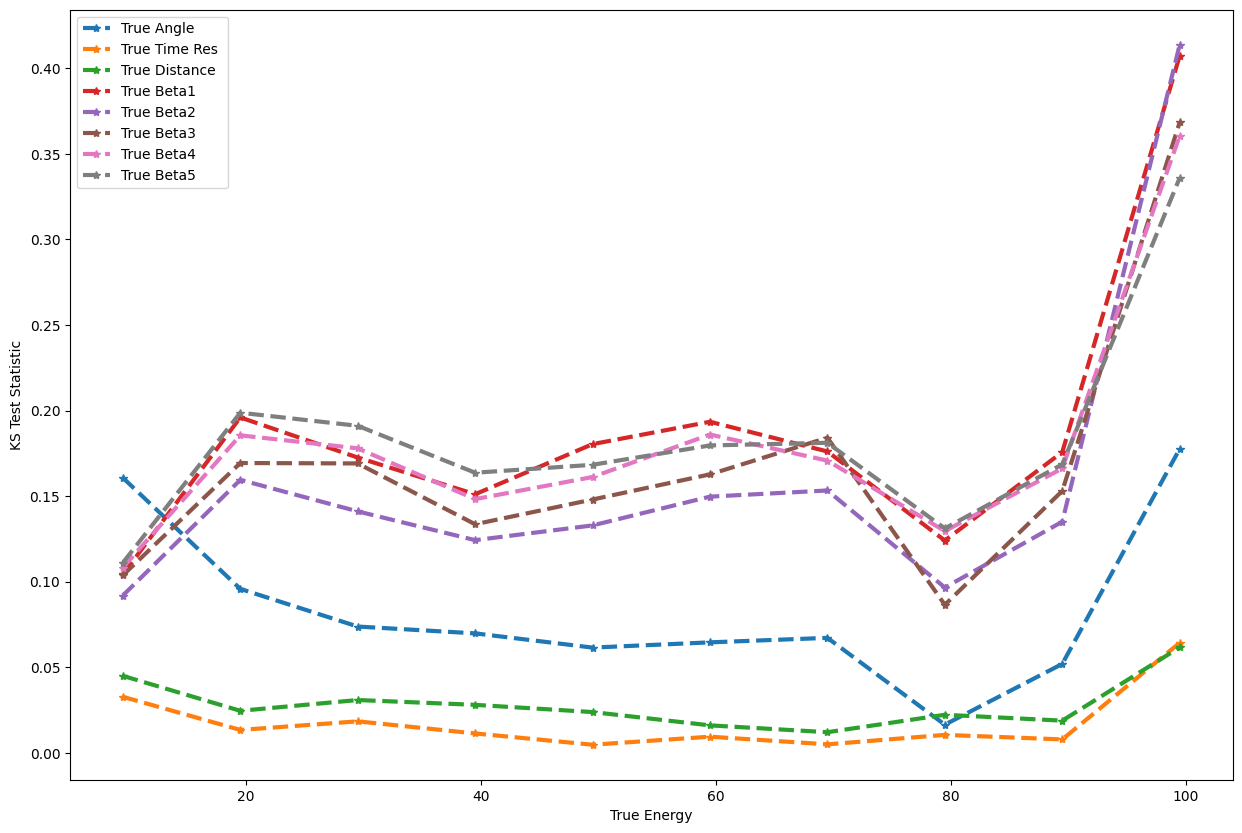

In [37]:
plt.figure(figsize=(15, 10))
plt.plot(bin_centers_angle_true, sep_var_angle_true, '*--', linewidth=3, label='True Angle ')
plt.plot(bin_centers_tRes_true, sep_var_tRes_true, '*--', linewidth=3, label='True Time Res ')
plt.plot(bin_centers_distance_true, sep_var_distance_true, '*--', linewidth=3, label='True Distance ')

plt.plot(bin_centers_beta1_true, sep_var_beta1_true, '*--', linewidth=3, label='True Beta1')
plt.plot(bin_centers_beta2_true, sep_var_beta2_true, '*--', linewidth=3, label='True Beta2')
plt.plot(bin_centers_beta3_true, sep_var_beta3_true, '*--', linewidth=3, label='True Beta3')
plt.plot(bin_centers_beta4_true, sep_var_beta4_true, '*--', linewidth=3, label='True Beta4')
plt.plot(bin_centers_beta5_true, sep_var_beta5_true, '*--', linewidth=3, label='True Beta5')

plt.ylabel('KS Test Statistic')
plt.xlabel('True Energy')
plt.legend()

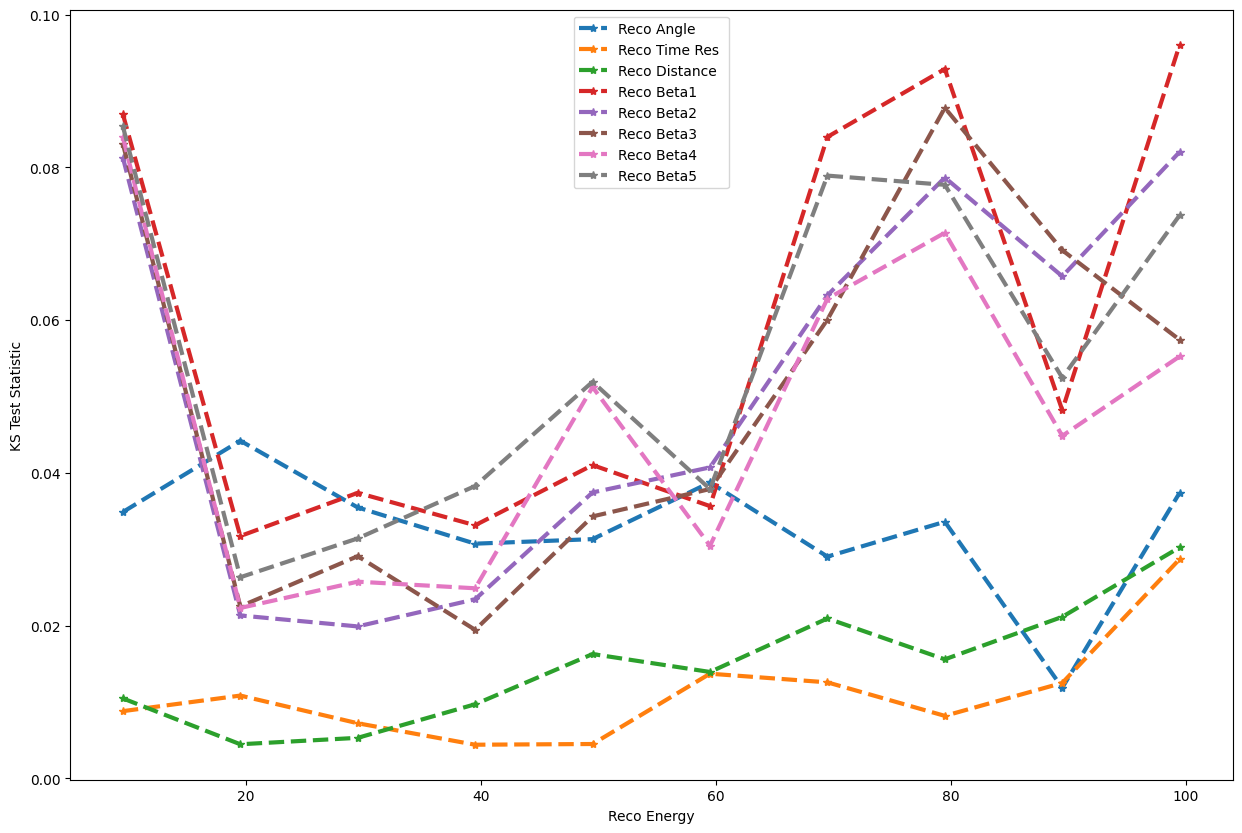

In [38]:
plt.figure(figsize=(15, 10))
plt.plot(bin_centers_angle_reco, sep_var_angle_reco, '*--', linewidth=3, label='Reco Angle ')
plt.plot(bin_centers_tRes_reco, sep_var_tRes_reco, '*--', linewidth=3, label='Reco Time Res ')
plt.plot(bin_centers_distance_reco, sep_var_distance_reco, '*--', linewidth=3, label='Reco Distance ')

plt.plot(bin_centers_beta1_reco, sep_var_beta1_reco, '*--', linewidth=3, label='Reco Beta1')
plt.plot(bin_centers_beta2_reco, sep_var_beta2_reco, '*--', linewidth=3, label='Reco Beta2')
plt.plot(bin_centers_beta3_reco, sep_var_beta3_reco, '*--', linewidth=3, label='Reco Beta3')
plt.plot(bin_centers_beta4_reco, sep_var_beta4_reco, '*--', linewidth=3, label='Reco Beta4')
plt.plot(bin_centers_beta5_reco, sep_var_beta5_reco, '*--', linewidth=3, label='Reco Beta5')

plt.ylabel('KS Test Statistic')
plt.xlabel('Reco Energy')
plt.legend()

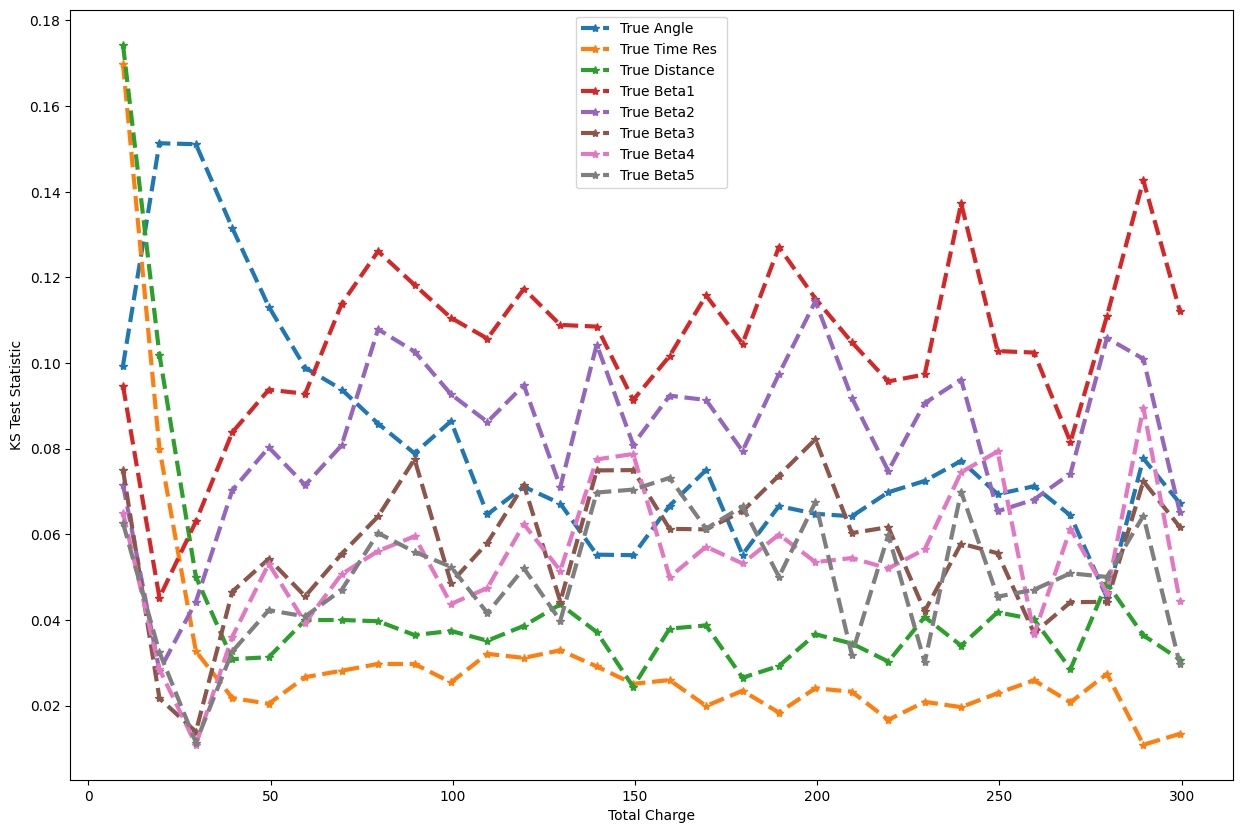

In [40]:
plt.figure(figsize=(15, 10))
plt.plot(cbin_centers_angle_true, csep_var_angle_true, '*--', linewidth=3, label='True Angle ')
plt.plot(cbin_centers_tRes_true, csep_var_tRes_true, '*--', linewidth=3, label='True Time Res ')
plt.plot(cbin_centers_distance_true, csep_var_distance_true, '*--', linewidth=3, label='True Distance ')

plt.plot(cbin_centers_beta1_true, csep_var_beta1_true, '*--', linewidth=3, label='True Beta1')
plt.plot(cbin_centers_beta2_true, csep_var_beta2_true, '*--', linewidth=3, label='True Beta2')
plt.plot(cbin_centers_beta3_true, csep_var_beta3_true, '*--', linewidth=3, label='True Beta3')
plt.plot(cbin_centers_beta4_true, csep_var_beta4_true, '*--', linewidth=3, label='True Beta4')
plt.plot(cbin_centers_beta5_true, csep_var_beta5_true, '*--', linewidth=3, label='True Beta5')

plt.ylabel('KS Test Statistic')
plt.xlabel('Total Charge')
plt.legend()

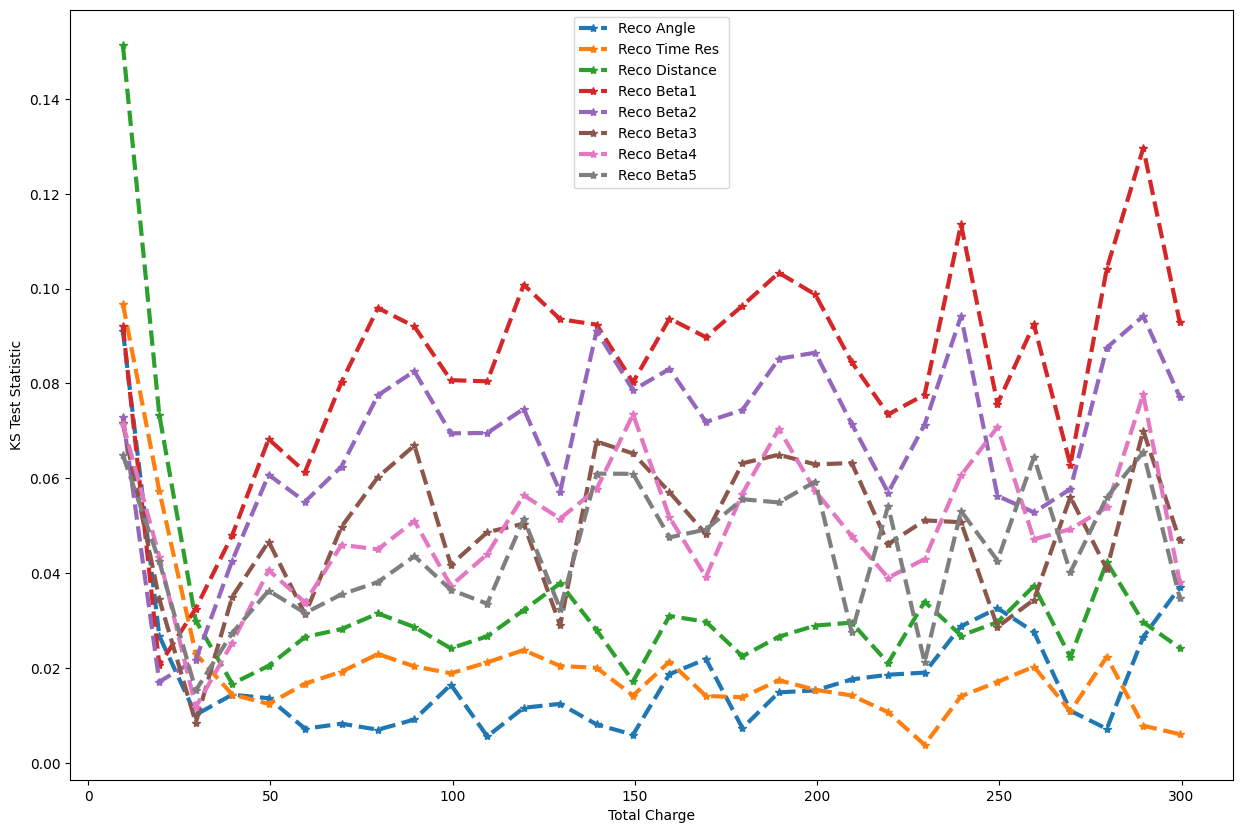

In [36]:
plt.figure(figsize=(15, 10))
plt.plot(cbin_centers_angle_reco, csep_var_angle_reco, '*--', linewidth=3, label='Reco Angle ')
plt.plot(cbin_centers_tRes_reco, csep_var_tRes_reco, '*--', linewidth=3, label='Reco Time Res ')
plt.plot(cbin_centers_distance_reco, csep_var_distance_reco, '*--', linewidth=3, label='Reco Distance ')

plt.plot(cbin_centers_beta1_reco, csep_var_beta1_reco, '*--', linewidth=3, label='Reco Beta1')
plt.plot(cbin_centers_beta2_reco, csep_var_beta2_reco, '*--', linewidth=3, label='Reco Beta2')
plt.plot(cbin_centers_beta3_reco, csep_var_beta3_reco, '*--', linewidth=3, label='Reco Beta3')
plt.plot(cbin_centers_beta4_reco, csep_var_beta4_reco, '*--', linewidth=3, label='Reco Beta4')
plt.plot(cbin_centers_beta5_reco, csep_var_beta5_reco, '*--', linewidth=3, label='Reco Beta5')

plt.ylabel('KS Test Statistic')
plt.xlabel('Total Charge')
plt.legend()